### 🎗️ Breast Cancer Prediction using KNN

Dataset
Breast Cancer Wisconsin Dataset

- **Target column:** `diagnosis`
- **M:** Malignant (cancer)
- **B:** Benign (not cancer)

**Goal:** Use KNN to predict whether a tumor is Malignant (M) or Benign (B).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load the Dataset

Load the CSV file and check the first few rows and missing values.

In [11]:
df = pd.read_csv("Breast_Cancer.csv")

In [12]:
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [13]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## 2. Data Cleaning

Remove unnecessary columns such as `id` and `Unnamed: 32`.

In [14]:
df = df.drop(columns=["Unnamed: 32"])

In [15]:
df = df.drop(columns=["id"])

## 3. Separate Features and Target

- X contains the tumor measurements.
- y contains the diagnosis.

In [16]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

## 4. Convert Target into Numbers

- M = 1 → Malignant
- B = 0 → Benign

KNN works with numerical values.

In [32]:
y = df["diagnosis"]
y = y.map({"M": 1, "B": 0})

print(y.head())

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [31]:
print(df["diagnosis"].unique())

['M' 'B']


## 5. Split the Dataset

Split the data into:

- 80% Training data
- 20% Testing data

In [ ]:
print(df["diagnosis"].unique())

['M' 'B']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Feature Scaling

KNN uses distance to find the nearest neighbors.

Therefore, we scale the features using StandardScaler.

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Create the KNN Model

We use K = 5.

The model looks at the 5 nearest data points to make a prediction.

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

## 8. Train the Model

Use the training data to train the KNN model.

In [21]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

## 9. Make Predictions

Use the trained model to predict the diagnosis of the test data.

In [22]:
y_pred = knn.predict(X_test)

## 10. Accuracy

Accuracy tells us how many predictions were correct.

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


## 11. Confusion Matrix

The confusion matrix shows the correct and incorrect predictions.

In [24]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[68  3]
 [ 3 40]]


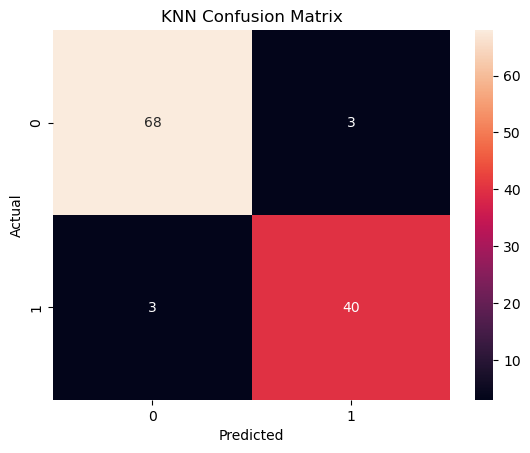

In [25]:
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

## 12. Classification Report

The classification report gives precision, recall, F1-score and support.

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 13. Show M and B Predictions

Convert:

- 1 → M (Malignant)
- 0 → B (Benign)

In [29]:
predicted = pd.Series(y_pred).map({1: "M", 0: "B"})

print("Predicted:")
print(predicted)

Predicted:
0      B
1      M
2      M
3      B
4      B
      ..
109    B
110    M
111    B
112    B
113    M
Length: 114, dtype: object


## Conclusion

The KNN model was trained to classify breast tumors as Malignant or Benign.

Feature scaling was performed because KNN uses distance.

The model was evaluated using Accuracy, Confusion Matrix and Classification Report.